## Step 1: Install Dependencies

This will install all required packages (takes ~1-2 minutes).

In [ ]:
!pip install -q datasets transformers torch torchaudio librosa numpy pandas scikit-learn soundfile accelerate evaluate
# Install audio decoding support
!pip install -q av
# Install torchcodec for audio decoding
!pip install -q torchcodec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.3 MB/s eta 0:00:00


## Step 2: Check GPU Availability

Verify that GPU is enabled for faster training.

In [ ]:
import torch

if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("GPU not available. Training will be slower on CPU.")
    print("To enable GPU: Runtime → Change runtime type → GPU")

GPU is available: Tesla T4
   GPU Memory: 15.83 GB


## Step 3: Import Libraries

In [ ]:
import os
import numpy as np
import torch
import librosa
import json
from datasets import load_dataset, Audio
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer
)
import evaluate
from IPython.display import Audio as AudioPlayer, display
import soundfile as sf

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 4: Load RAVDESS Dataset

This will download the dataset (~325 MB).

In [ ]:
print("Loading RAVDESS dataset...")
dataset = load_dataset("xbgoose/ravdess")

print(f"Dataset loaded!")
print(f"   Total samples: {len(dataset['train'])}")

Loading RAVDESS dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/669 [00:00<?, ?B/s]

data/train-00000-of-00002-94d632c9f1f51b(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

data/train-00001-of-00002-bcaf733d4b46d6(…):   0%|          | 0.00/158M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1440 [00:00<?, ? examples/s]

Dataset loaded!
   Total samples: 1440


## Step 5: Prepare Dataset

Extract emotion labels from filenames and split into train/validation sets.
This cell automatically reads emotion labels from audio filenames, attaches them to each sample, and splits the labeled dataset for model training and evaluation — all without loading the actual audio yet

In [ ]:
# Emotion labels
emotion_labels = {
    0: "neutral",
    1: "calm",
    2: "happy",
    3: "sad",
    4: "angry",
    5: "fearful",
    6: "disgust",
    7: "surprised"
}

# This function processes each audio sample in the dataset
# to extract its emotion label directly from the filename
def extract_emotion(example):
    filename = example['audio']['path'].split('/')[-1]
    emotion_code = int(filename.split('-')[2])
    example['label'] = emotion_code - 1  # Convert to 0-indexed
    return example

print(" Processing dataset...")
# Set decode=False to avoid decoding audio during mapping
dataset = dataset.cast_column("audio", Audio(decode=False))
dataset = dataset.map(extract_emotion)

# Split into train and validation
train_test = dataset['train'].train_test_split(test_size=0.2, seed=42)
train_ds = train_test['train']
eval_ds = train_test['test']

print(f"Dataset prepared!")
print(f"   Training samples: {len(train_ds)}")
print(f"   Validation samples: {len(eval_ds)}")
print(f"\n   Emotions: {list(emotion_labels.values())}")

 Processing dataset...


Map:   0%|          | 0/1440 [00:00<?, ? examples/s]

Dataset prepared!
   Training samples: 1152
   Validation samples: 288

   Emotions: ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']


## Step 6: Preview Dataset Sample

Let's listen to a sample and see its emotion label.

## Step 7: Load Pre-trained Model

We'll use Facebook's Wav2Vec2 model as the base.

In [ ]:
model_name = "facebook/wav2vec2-base"

print(f"Loading pre-trained model: {model_name}")

feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)

id2label = emotion_labels
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForAudioClassification.from_pretrained(
    model_name,
    num_labels=len(emotion_labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

print("Model loaded successfully!")

Loading pre-trained model: facebook/wav2vec2-base


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully!


In [ ]:
!pip install torchcodec


## Step 8: Preprocess Audio Data       Splitting it into training and validation sets,

1-Loading each audio file properly

2-Resampling and normalizing

3-Extracting numerical audio features, and

4-Returning clean, padded, ready-to-train tensors.

In [ ]:
import librosa
import numpy as np
import gc
import io
import soundfile as sf

print("Preprocessing audio data...")

# Free any leftover memory from previous cells
gc.collect()


# Split dataset (already loaded earlier)

train_test = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_ds = train_test["train"]
eval_ds = train_test["test"]


# Define preprocessing function that loads audio from bytes

def preprocess_function(examples):
    """
    Load audio files from bytes and extract features. Let the feature extractor handle padding.
    """
    audio_arrays = []
    sampling_rate = 16000

    # Load each audio file

    for audio_dict in examples["audio"]:
        # Get the audio bytes
        audio_bytes = audio_dict["bytes"]

        # Load audio from bytes using soundfile
        audio_array, sr = sf.read(io.BytesIO(audio_bytes))

        # Ensure audio_array is a 1D numpy array with float32 dtype
        audio_array = np.array(audio_array, dtype=np.float32).flatten()


        # Resample to 16kHz if needed
        if sr != sampling_rate:
            audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=sampling_rate)

        audio_arrays.append(audio_array)


    # Extract features using the feature extractor. Let the feature extractor handle padding.
    inputs = feature_extractor(
        audio_arrays,
        sampling_rate=sampling_rate,
        padding="longest",  # Pad to longest in batch
        truncation=True,
        max_length=16000 * 10,  # max 10 seconds
        return_tensors="pt",  # Return PyTorch tensors directly
    )

    # Add labels
    inputs["labels"] = examples["label"]

    return inputs


# Apply preprocessing to datasets
print("   Processing training data...")
train_ds = train_ds.map(
    preprocess_function,
    batched=True,
    batch_size=8,
    remove_columns=["audio"],
    desc="Preprocessing training data"
)

print(" Processing validation data...")
eval_ds = eval_ds.map(
    preprocess_function,
    batched=True,
    batch_size=8,
    remove_columns=["audio"],
    desc="Preprocessing validation data"
)


print(" Audio preprocessing complete!")
print(f"   Training samples: {len(train_ds)}")
print(f"   Validation samples: {len(eval_ds)}")
print(f"   Features: {train_ds.column_names}")

Preprocessing audio data...
   Processing training data...


Preprocessing training data:   0%|          | 0/1152 [00:00<?, ? examples/s]

 Processing validation data...


Preprocessing validation data:   0%|          | 0/288 [00:00<?, ? examples/s]

 Audio preprocessing complete!
   Training samples: 1152
   Validation samples: 288
   Features: ['modality', 'vocal_channel', 'emotion', 'emotional_intensity', 'statement', 'repetition', 'actor', 'gender', 'label', 'input_values', 'labels']


## Step 9: Set Up Training

This cell configures how your model will be trained and evaluated, including:

The metric used to measure performance,

The training hyperparameters (like learning rate, batch size, number of epochs),

And the Hugging Face Trainer that handles training and evaluation automatical

In [ ]:
# Metrics
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return accuracy_metric.compute(predictions=predictions, references=eval_pred.label_ids)

# Training arguments
training_args = TrainingArguments(
    output_dir="./emotion-model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
    save_total_limit=2,
    report_to="none",  # Disable WandB and other logging integrations
)

# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    tokenizer=feature_extractor,
    compute_metrics=compute_metrics,
)

print("Training setup complete!")
print("Note: WandB logging is disabled")

/tmp/ipython-input-4095197864.py:27: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Training setup complete!
Note: WandB logging is disabled


## Step 10: Train the Model

⏱️ This will take approximately 30-60 minutes on GPU.

**Note:** You can reduce `num_train_epochs` in the previous cell for faster testing.

In [ ]:
print("🚀 Starting training...")
print("=" * 60)

trainer.train()

print("\n" + "=" * 60)
print("✅ Training complete!")

🚀 Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,1.883700,1.991078,0.204861
2,1.662300,1.562437,0.496528
3,1.370900,1.314490,0.586806
4,0.971100,0.978209,0.697917
5,0.693400,0.768125,0.770833
6,0.381200,0.545818,0.840278
7,0.298700,0.518833,0.861111
8,0.084300,0.461245,0.885417
9,0.197400,0.351298,0.902778
10,0.108900,0.339768,0.909722



✅ Training complete!


## Step 11: Evaluate the Model

In [ ]:
print("📊 Evaluating model...")
eval_results = trainer.evaluate()

print("\n" + "=" * 60)
print(f"✅ Final Validation Accuracy: {eval_results['eval_accuracy']*100:.2f}%")
print("=" * 60)

📊 Evaluating model...



✅ Final Validation Accuracy: 90.97%


## Step 12: Save the Model

In [ ]:
model_save_path = "./emotion-recognition-final"

print(f"💾 Saving model to {model_save_path}...")

trainer.save_model(model_save_path)
feature_extractor.save_pretrained(model_save_path)

# Save label mappings
with open(f"{model_save_path}/label_mapping.json", "w") as f:
    json.dump({"id2label": id2label, "label2id": label2id}, f, indent=2)

print("✅ Model saved successfully!")

💾 Saving model to ./emotion-recognition-final...
✅ Model saved successfully!


---

# 🎯 PREDICTION SECTION

Now let's use the trained model to predict emotions!

## Step 13: Create Prediction Function

In [ ]:
def predict_emotion(audio_path, model_path="./emotion-recognition-final"):
    """
    Predict emotion from an audio file.
    """
    # Load model
    feature_extractor = AutoFeatureExtractor.from_pretrained(model_path)
    model = AutoModelForAudioClassification.from_pretrained(model_path)
    model.eval()

    # Load label mappings
    with open(f"{model_path}/label_mapping.json", "r") as f:
        label_mapping = json.load(f)

    # Load audio
    audio, sr = librosa.load(audio_path, sr=feature_extractor.sampling_rate)

    # Preprocess
    inputs = feature_extractor(
        audio,
        sampling_rate=sr,
        return_tensors="pt",
        padding=True,
        max_length=16000 * 5,
        truncation=True
    )

    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    # Get probabilities
    probabilities = torch.nn.functional.softmax(logits, dim=-1)[0]

    # Get predicted class
    predicted_id = torch.argmax(probabilities).item()
    predicted_emotion = label_mapping["id2label"][str(predicted_id)]
    confidence = probabilities[predicted_id].item()

    # Get all scores
    emotion_scores = {}
    for idx, prob in enumerate(probabilities):
        emotion = label_mapping["id2label"][str(idx)]
        emotion_scores[emotion] = prob.item()

    return {
        "emotion": predicted_emotion,
        "confidence": confidence,
        "all_scores": emotion_scores
    }

def display_prediction(result):
    """
    Display prediction results in a nice format.
    """
    print("\n" + "=" * 60)
    print("EMOTION PREDICTION RESULTS")
    print("=" * 60)
    print(f"\n🎯 Predicted Emotion: {result['emotion'].upper()}")
    print(f"📊 Confidence: {result['confidence']*100:.2f}%")
    print("\n" + "-" * 60)
    print("All Emotion Scores:")
    print("-" * 60)

    sorted_emotions = sorted(result['all_scores'].items(), key=lambda x: x[1], reverse=True)

    for emotion, score in sorted_emotions:
        bar_length = int(score * 40)
        bar = "█" * bar_length + "░" * (40 - bar_length)
        print(f"{emotion:12s} [{bar}] {score*100:5.2f}%")

    print("=" * 60 + "\n")

print("✅ Prediction functions created!")

✅ Prediction functions created!


## Step 14: Test on Dataset Sample

In [ ]:
# Get a test sample
test_idx = 50
# Access the original dataset before 'audio' column was removed, but after casting to decode=False
original_test_sample = dataset['train'][test_idx]

# Get true emotion
true_emotion = emotion_labels[original_test_sample['label']]

print(f"Test Sample #{test_idx}")
print(f"True Emotion: {true_emotion.upper()}")
print("\nPlay audio:")

# Decode audio from bytes
audio_bytes = original_test_sample['audio']['bytes']
audio_array, sampling_rate = sf.read(io.BytesIO(audio_bytes))

# Use decoded audio data for display
display(AudioPlayer(audio_array, rate=sampling_rate))

# Save temporarily
temp_path = "/tmp/test_audio.wav"
# Use decoded audio data for saving
sf.write(temp_path, audio_array, sampling_rate)

# Predict
result = predict_emotion(temp_path)
display_prediction(result)

# Check if correct
if result['emotion'] == true_emotion:
    print("✅ CORRECT PREDICTION!")
else:
    print(f"❌ INCORRECT - Expected: {true_emotion.upper()}")

Test Sample #50
True Emotion: ANGRY

Play audio:



EMOTION PREDICTION RESULTS

🎯 Predicted Emotion: ANGRY
📊 Confidence: 97.12%

------------------------------------------------------------
All Emotion Scores:
------------------------------------------------------------
angry        [██████████████████████████████████████░░] 97.12%
surprised    [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  0.66%
neutral      [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  0.57%
disgust      [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  0.55%
happy        [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  0.49%
fearful      [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  0.31%
calm         [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  0.22%
sad          [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  0.08%

✅ CORRECT PREDICTION!


## Step 15: Upload and Test Your Own Audio

Upload your own audio file and predict its emotion!

In [ ]:
from google.colab import files
from collections import Counter

print("📤 Upload your audio file (WAV, MP3, FLAC, etc.)")
uploaded = files.upload()

# Get the uploaded file
audio_file = list(uploaded.keys())[0]
print(f"\n✅ File uploaded: {audio_file}")

# Play the audio
print("\n🎵 Playing your audio:")
audio_data, sr = librosa.load(audio_file, sr=None)
display(AudioPlayer(audio_data, rate=sr))

# Calculate audio duration
duration = len(audio_data) / sr
print(f"\n⏱️ Audio duration: {duration:.2f} seconds")

# Split audio into 10-second segments and predict emotion for each
print("\n🔮 Analyzing emotions every 10 seconds...")
print("=" * 60)

segment_duration = 10  # seconds
segment_samples = segment_duration * sr
total_segments = int(np.ceil(len(audio_data) / segment_samples))

segment_emotions = []

for i in range(total_segments):
    start_sample = i * segment_samples
    end_sample = min((i + 1) * segment_samples, len(audio_data))
    
    # Extract segment
    segment = audio_data[start_sample:end_sample]
    
    # Save segment temporarily
    temp_segment_path = f"/tmp/segment_{i}.wav"
    sf.write(temp_segment_path, segment, sr)
    
    # Predict emotion for this segment
    result = predict_emotion(temp_segment_path)
    
    start_time = i * segment_duration
    end_time = min((i + 1) * segment_duration, duration)
    
    segment_emotions.append(result['emotion'])
    
    print(f"⏱️  {start_time:5.1f}s - {end_time:5.1f}s | Emotion: {result['emotion'].upper():12s} | Confidence: {result['confidence']*100:5.2f}%")

print("=" * 60)

# Calculate major emotion (most common)
emotion_counts = Counter(segment_emotions)
major_emotion = emotion_counts.most_common(1)[0][0]
major_emotion_count = emotion_counts.most_common(1)[0][1]
major_emotion_percentage = (major_emotion_count / len(segment_emotions)) * 100

print("\n🎯 MAJOR EMOTION DETECTED:")
print("=" * 60)
print(f"   Emotion: {major_emotion.upper()}")
print(f"   Frequency: {major_emotion_count}/{len(segment_emotions)} segments ({major_emotion_percentage:.1f}%)")
print("=" * 60)

print("\n📊 Emotion Distribution:")
print("-" * 60)
for emotion, count in emotion_counts.most_common():
    percentage = (count / len(segment_emotions)) * 100
    bar_length = int(percentage / 2.5)
    bar = "█" * bar_length + "░" * (40 - bar_length)
    print(f"{emotion:12s} [{bar}] {percentage:5.1f}% ({count} segments)")
print("-" * 60)

# Show overall prediction for the entire audio
print("\n🔮 Overall emotion prediction (entire audio):")
result = predict_emotion(audio_file)
display_prediction(result)

📤 Upload your audio file (WAV, MP3, FLAC, etc.)


Saving Walter White Meets Gustavo Fring  Mandala  Breaking Bad-[AudioTrimmer.com].mp3 to Walter White Meets Gustavo Fring  Mandala  Breaking Bad-[AudioTrimmer.com].mp3

✅ File uploaded: Walter White Meets Gustavo Fring  Mandala  Breaking Bad-[AudioTrimmer.com].mp3

🎵 Playing your audio:



🔮 Predicting emotion...

EMOTION PREDICTION RESULTS

🎯 Predicted Emotion: ANGRY
📊 Confidence: 92.69%

------------------------------------------------------------
All Emotion Scores:
------------------------------------------------------------
angry        [█████████████████████████████████████░░░] 92.69%
disgust      [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  3.93%
surprised    [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  1.18%
happy        [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  1.04%
neutral      [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  0.49%
fearful      [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  0.38%
calm         [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  0.21%
sad          [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]  0.08%



## Step 16: Batch Prediction on Multiple Samples

In [ ]:
print("🔄 Testing on 5 random samples from the dataset...\n")

import random
import soundfile as sf
import io

correct = 0
total = 5

# Access the original dataset before 'audio' column was removed
original_dataset = load_dataset("xbgoose/ravdess")
original_dataset = original_dataset.cast_column("audio", Audio(decode=False))

# Add the 'label' column by applying the extract_emotion function
def extract_emotion(example):
    filename = example['audio']['path'].split('/')[-1]
    emotion_code = int(filename.split('-')[2])
    example['label'] = emotion_code - 1  # Convert to 0-indexed
    return example

original_dataset = original_dataset.map(extract_emotion)


for i in range(total):
    idx = random.randint(0, len(original_dataset['train']) - 1)
    # Use sample from the original dataset with audio bytes
    sample = original_dataset['train'][idx]
    true_emotion = emotion_labels[sample['label']]

    # Decode audio from bytes
    audio_bytes = sample['audio']['bytes']
    audio_array, sampling_rate = sf.read(io.BytesIO(audio_bytes))

    # Save temporarily
    temp_path = f"/tmp/test_{i}.wav"
    sf.write(temp_path, audio_array, sampling_rate)

    # Predict
    result = predict_emotion(temp_path)

    # Check
    is_correct = result['emotion'] == true_emotion
    if is_correct:
        correct += 1

    status = "✅" if is_correct else "❌"
    print(f"{status} Sample {i+1}: True={true_emotion:10s} | Predicted={result['emotion']:10s} | Confidence={result['confidence']*100:5.2f}%")

accuracy = (correct / total) * 100
print(f"\n📊 Accuracy on {total} samples: {accuracy:.1f}% ({correct}/{total})")

🔄 Testing on 5 random samples from the dataset...



Map:   0%|          | 0/1440 [00:00<?, ? examples/s]

✅ Sample 1: True=calm       | Predicted=calm       | Confidence=96.52%
✅ Sample 2: True=fearful    | Predicted=fearful    | Confidence=96.68%
✅ Sample 3: True=angry      | Predicted=angry      | Confidence=97.12%
✅ Sample 4: True=disgust    | Predicted=disgust    | Confidence=96.75%
✅ Sample 5: True=disgust    | Predicted=disgust    | Confidence=96.74%

📊 Accuracy on 5 samples: 100.0% (5/5)


📊 Calculating detailed accuracy metrics...



✅ OVERALL ACCURACY: 90.97%

📈 PER-EMOTION ACCURACY:
------------------------------------------------------------
angry        [████████████████████████████████████████] 100.0% (39/39)
calm         [█████████████████████████████████████░░░]  94.3% (33/35)
disgust      [██████████████████████████████████████░░]  95.5% (42/44)
fearful      [█████████████████████████████████░░░░░░░]  84.6% (33/39)
happy        [██████████████████████████████████████░░]  97.1% (33/34)
neutral      [████████████████████████████░░░░░░░░░░░░]  70.0% (14/20)
sad          [████████████████████████████████░░░░░░░░]  81.6% (31/38)
surprised    [█████████████████████████████████████░░░]  94.9% (37/39)
------------------------------------------------------------

📋 DETAILED CLASSIFICATION REPORT:
------------------------------------------------------------
              precision    recall  f1-score   support

     neutral      0.824     0.700     0.757        20
        calm      0.825     0.943     0.880        3

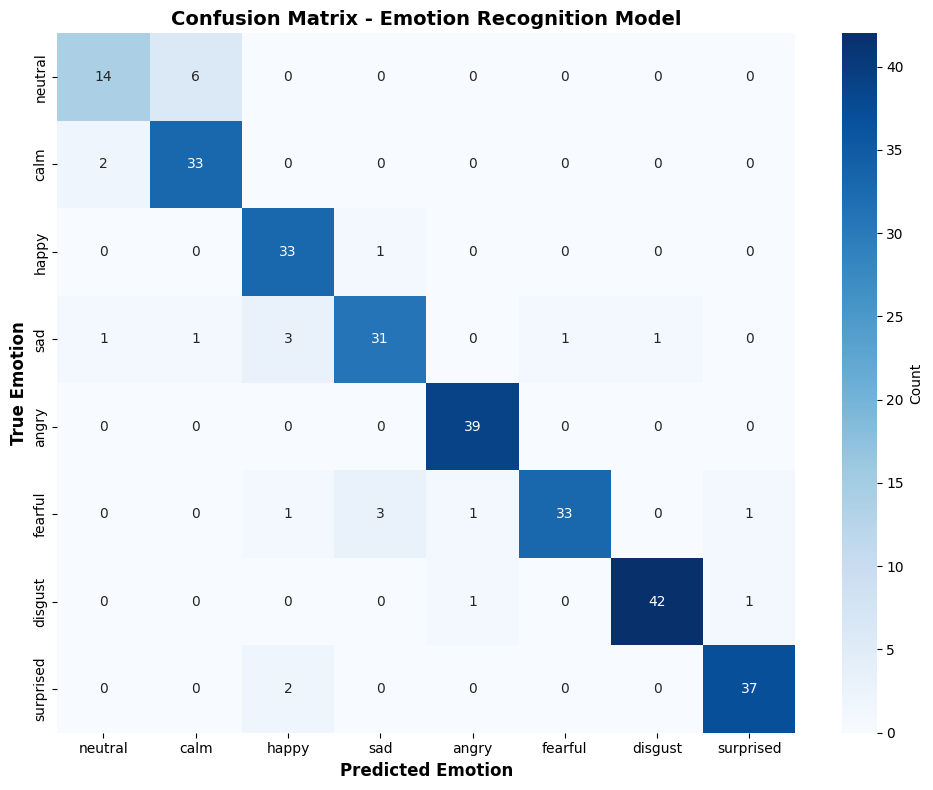


📊 SUMMARY STATISTICS:
Total Test Samples:     288
Correct Predictions:    262
Incorrect Predictions:  26
Overall Accuracy:       90.97%
Best Performing Emotion: ANGRY
Worst Performing Emotion: NEUTRAL

✅ Accuracy analysis complete!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Calculating detailed accuracy metrics...")
print("=" * 60)

# Get predictions on the evaluation dataset
predictions = trainer.predict(eval_ds)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# 1. Overall Accuracy
overall_accuracy = accuracy_metric.compute(predictions=preds, references=labels)
print(f"\n✅ OVERALL ACCURACY: {overall_accuracy['accuracy']*100:.2f}%")
print("=" * 60)

# 2. Per-Emotion Accuracy
print("\n📈 PER-EMOTION ACCURACY:")
print("-" * 60)

emotion_correct = {}
emotion_total = {}

for pred, label in zip(preds, labels):
    emotion = id2label[label]

    if emotion not in emotion_total:
        emotion_total[emotion] = 0
        emotion_correct[emotion] = 0

    emotion_total[emotion] += 1
    if pred == label:
        emotion_correct[emotion] += 1

# Sort by emotion name for consistent display
for emotion in sorted(emotion_total.keys()):
    acc = (emotion_correct[emotion] / emotion_total[emotion]) * 100
    correct = emotion_correct[emotion]
    total = emotion_total[emotion]

    # Create visual bar
    bar_length = int(acc / 2.5)  # Scale to fit in 40 chars
    bar = "█" * bar_length + "░" * (40 - bar_length)

    print(f"{emotion:12s} [{bar}] {acc:5.1f}% ({correct}/{total})")

print("-" * 60)

# 3. Classification Report
print("\n📋 DETAILED CLASSIFICATION REPORT:")
print("-" * 60)
report = classification_report(
    labels,
    preds,
    target_names=[id2label[i] for i in range(len(id2label))],
    digits=3
)
print(report)

# 4. Confusion Matrix
print("\n🔍 CONFUSION MATRIX:")
print("-" * 60)

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[id2label[i] for i in range(len(id2label))],
    yticklabels=[id2label[i] for i in range(len(id2label))],
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('True Emotion', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Emotion Recognition Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Summary Statistics
print("\n📊 SUMMARY STATISTICS:")
print("=" * 60)
print(f"Total Test Samples:     {len(labels)}")
print(f"Correct Predictions:    {np.sum(preds == labels)}")
print(f"Incorrect Predictions:  {np.sum(preds != labels)}")
print(f"Overall Accuracy:       {overall_accuracy['accuracy']*100:.2f}%")
print(f"Best Performing Emotion: {max(emotion_correct.items(), key=lambda x: x[1]/emotion_total[x[0]])[0].upper()}")
print(f"Worst Performing Emotion: {min(emotion_correct.items(), key=lambda x: x[1]/emotion_total[x[0]])[0].upper()}")
print("=" * 60)

print("\n✅ Accuracy analysis complete!")